In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [2]:
customers = pd.read_csv(r"Dataset/olist_customers_dataset.csv")

orders = pd.read_csv(r"Dataset/olist_orders_dataset.csv")

order_items = pd.read_csv(r"Dataset/olist_order_items_dataset.csv")

products = pd.read_csv("Dataset/olist_products_dataset.csv")

payments = pd.read_csv("Dataset/olist_order_payments_dataset.csv")

reviews = pd.read_csv("Dataset/olist_order_reviews_dataset.csv")

sellers = pd.read_csv("Dataset/olist_sellers_dataset.csv")

translation = pd.read_csv(
    "Dataset/product_category_name_translation.csv"
)

geolocation = pd.read_csv(
    "Dataset/olist_geolocation_dataset.csv"
)

In [3]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers
}

for name, df in datasets.items():
    print("="*60)
    print(name.upper())
    print("="*60)

    print("Shape:", df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicates")
    print(df.duplicated().sum())

    print()

CUSTOMERS
Shape: (99441, 5)

Columns
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicates
0

ORDERS
Shape: (99441, 8)

Columns
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicates
0

ORDER_ITEMS
Shape: (112650, 7)

Columns
['order_id', 'order_item_id', 'product_id', 'seller_id'

**DATA CLEANING**

In [4]:
#Remove Duplicates
for name, df in datasets.items():
    datasets[name] = df.drop_duplicates()

In [5]:
#convert Date Columns
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

In [6]:
#Fill missing product Categories
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("unknown")
)

**MERGE DATASET**

In [7]:
merged = (
    order_items
    .merge(products,
           on="product_id",
           how="left")

    .merge(translation,
           on="product_category_name",
           how="left")

    .merge(orders,
           on="order_id",
           how="left")

    .merge(customers,
           on="customer_id",
           how="left")

    .merge(payments,
           on="order_id",
           how="left")

    .merge(reviews,
           on="order_id",
           how="left")

    .merge(sellers,
           on="seller_id",
           how="left")
)

print(merged.shape)

(118310, 40)


In [8]:
#Create Revenue Column
merged["revenue"] = (
    merged["price"] +
    merged["freight_value"]
)

**BUSINESS QUESTION 1**

In [9]:
# Highest Revenue Categories
revenue_category = (
    merged
    .groupby("product_category_name_english")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_category.head(10))

product_category_name_english
health_beauty            1491397.76
watches_gifts            1358845.59
bed_bath_table           1327662.02
sports_leisure           1205197.85
computers_accessories    1104362.03
furniture_decor           955367.22
housewares                823623.50
cool_stuff                752702.21
auto                      714431.95
garden_tools              625387.31
Name: revenue, dtype: float64


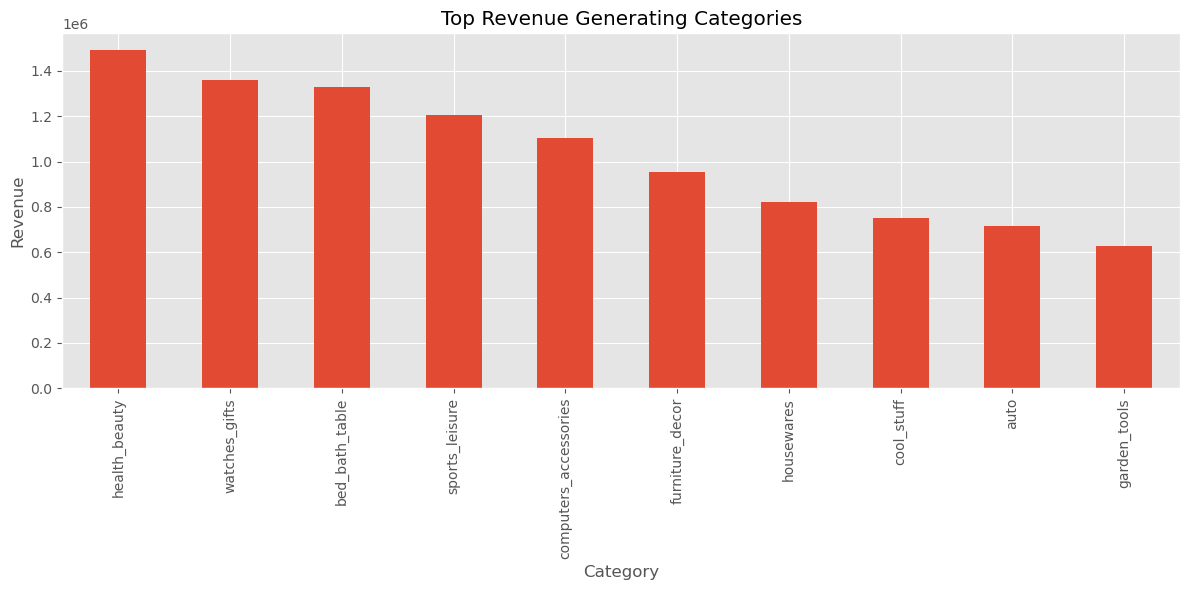

In [10]:
# Visualization
plt.figure(figsize=(12,6))

revenue_category.head(10).plot(
    kind="bar"
)

plt.title("Top Revenue Generating Categories")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

**BUSINESS QUESTION 2**

In [11]:
# Highest Sales Region
state_sales = (
    merged
    .groupby("customer_state")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))

customer_state
SP    6234533.82
RJ    2247128.32
MG    1928571.09
RS     934286.75
PR     832059.40
BA     650220.38
SC     632514.14
GO     368997.61
DF     367750.15
ES     336438.54
Name: revenue, dtype: float64


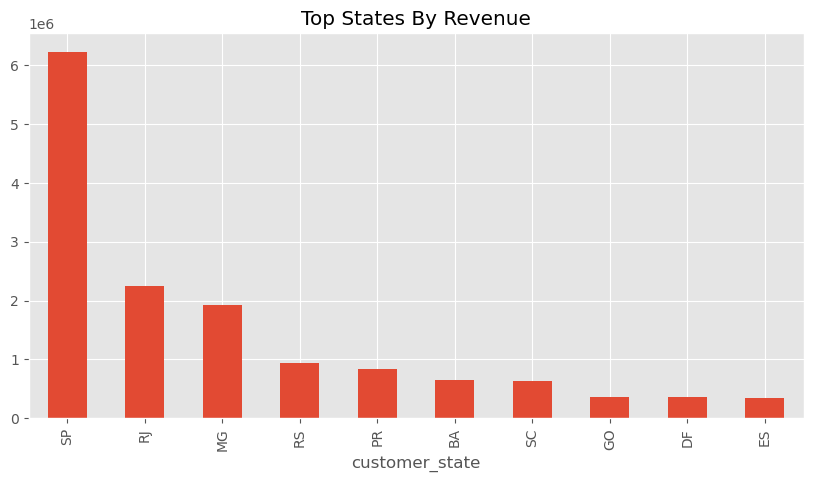

In [12]:
plt.figure(figsize=(10,5))

state_sales.head(10).plot(
    kind="bar"
)

plt.title("Top States By Revenue")
plt.show()

**BUSINESS QUESTION 3**

In [13]:
# Highest value consumer
customer_value = (
    merged
    .groupby("customer_unique_id")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(customer_value.head(10))

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
8af7ac63b2efbcbd88e5b11505e8098a    13281.71
c4b224d2c784bae11ae98b6ae9f2454c    11111.40
85963fd37bfd387aa6d915d8a1065486    10553.28
be74c431147c32ab2d7c7cef5e4a995f    10055.22
edf81e1f3070b9dac83ec83dacdbb9bc     8389.52
58483a1c055dfb600f57c5b867174542     8068.88
1033eef37a760a832f9b2332ce23fdc5     8030.46
da122df9eeddfedc1dc1f5349a1a690c     7571.63
301d1ce5a76b7e1bc47e5115bf5eb6ba     7413.70
Name: revenue, dtype: float64


In [14]:
customer_summary = (
    merged
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id","nunique"),
        total_spent=("revenue","sum")
    )
)

customer_summary.head()

,total_orders,total_spent
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
0000f46a3911fa3c0805444483337064,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,43.62
0004aac84e0df4da2b147fca70cf8255,1,196.89


**BUSINESS QUESTION 4**

In [15]:
# Purchase behavior
purchase_frequency = (
    merged
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

purchase_frequency.describe()

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

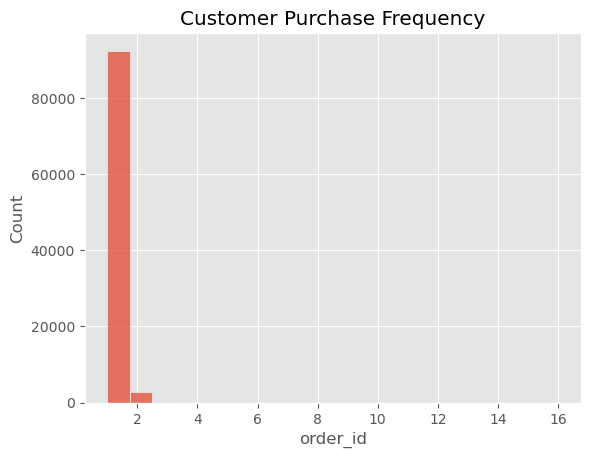

In [16]:
sns.histplot(
    purchase_frequency,
    bins=20
)

plt.title(
    "Customer Purchase Frequency"
)

plt.show()

**Business Analysis Question 5**

In [17]:
#Top products
top_products = (
    merged
    .groupby("product_id")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_id
bb50f2e236e5eea0100680137654686c    72808.96
d1c427060a0f73f6b889a5c7c61f2ac4    63846.01
6cdd53843498f92890544667809f1595    60229.82
d6160fb7873f184099d9bc95e30376af    58608.48
99a4788cb24856965c36a24e339b6058    55256.44
3dd2a17168ec895c781a9191c1e95ad7    48913.68
25c38557cf793876c5abdd5931f922db    46466.21
aca2eb7d00ea1a7b8ebd4e68314663af    45522.32
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
53b36df67ebb7c41585e8d54d6772e08    40467.30
Name: revenue, dtype: float64


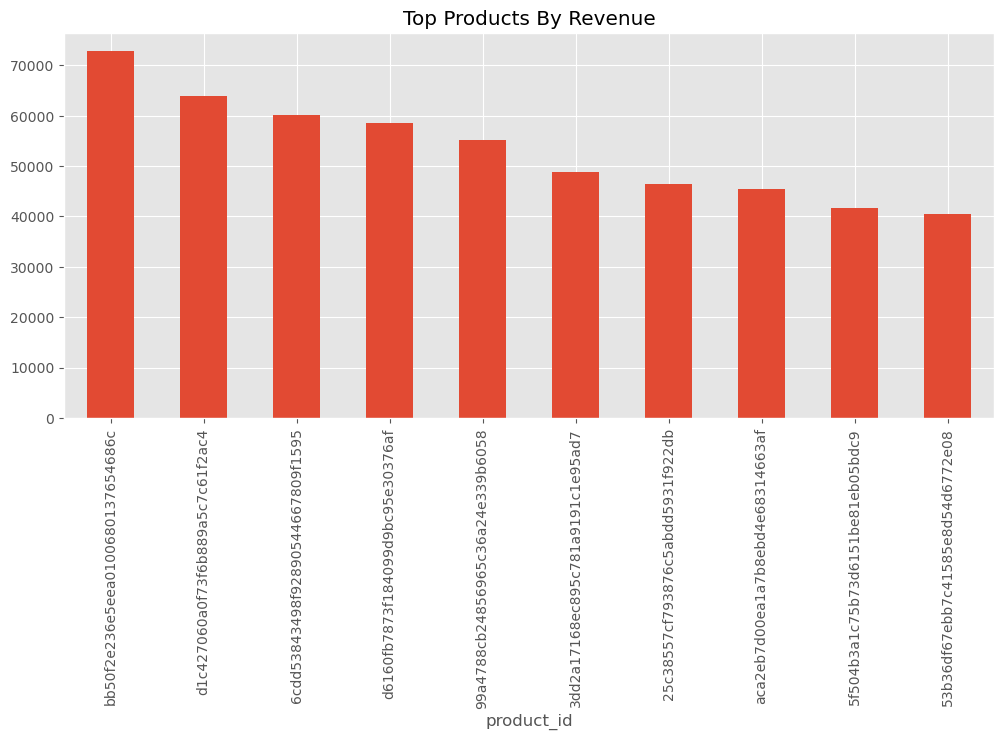

In [18]:
top_products.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top Products By Revenue"
)

plt.show()

**Business Analysis Question 6**

In [19]:
# Payment Analysis
payment_analysis = (
    merged
    .groupby("payment_type")
    .agg(
        transactions=("order_id","count"),
        revenue=("revenue","sum")
    )
)

print(payment_analysis)

              transactions      revenue
payment_type                           
boleto               23018   2859446.84
credit_card          87258  12776455.36
debit_card            1699    216038.08
voucher               6332    791647.56


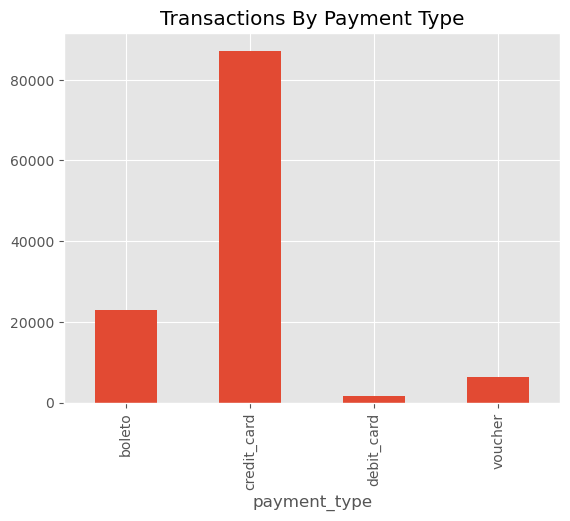

In [20]:
payment_analysis["transactions"].plot(
    kind="bar"
)

plt.title(
    "Transactions By Payment Type"
)

plt.show()

**Business Question 7**

In [21]:
#Top sellers
seller_revenue = (
    merged
    .groupby("seller_id")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(
    seller_revenue.head(10)
)

seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    254387.70
4a3ca9315b744ce9f8e9374361493884    253535.64
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    198621.24
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    178696.05
7a67c85e85bb2ce8582c35f2203ad736    172887.23
955fee9216a65b617aa5c0531780ce60    163275.71
Name: revenue, dtype: float64


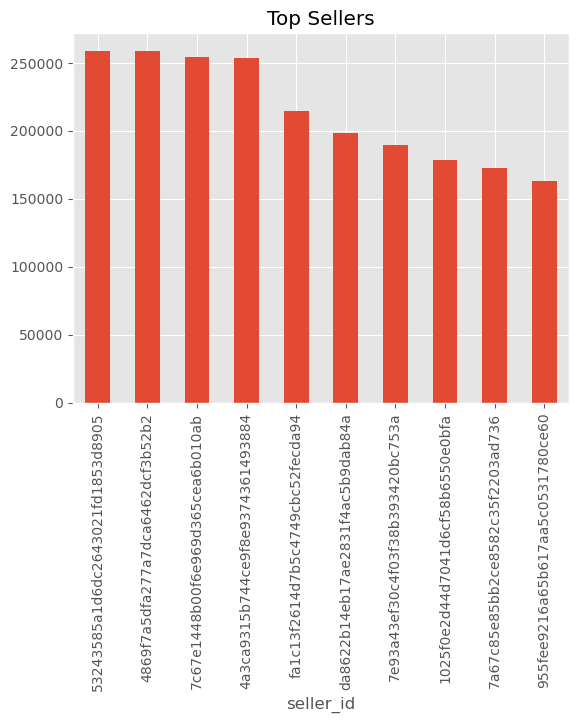

In [22]:
seller_revenue.head(10).plot(
    kind="bar"
)

plt.title(
    "Top Sellers"
)

plt.show()

**Business Question 8**

In [23]:
# Review By Category
review_analysis = (
    merged
    .groupby(
        "product_category_name_english"
    )
    ["review_score"]
    .mean()
    .sort_values(
        ascending=False
    )
)

print(review_analysis.head(10))

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.438503
books_imported                           4.419355
flowers                                  4.419355
costruction_tools_tools                  4.415842
books_technical                          4.375465
food_drink                               4.324138
small_appliances_home_oven_and_coffee    4.320513
luggage_accessories                      4.295945
Name: review_score, dtype: float64


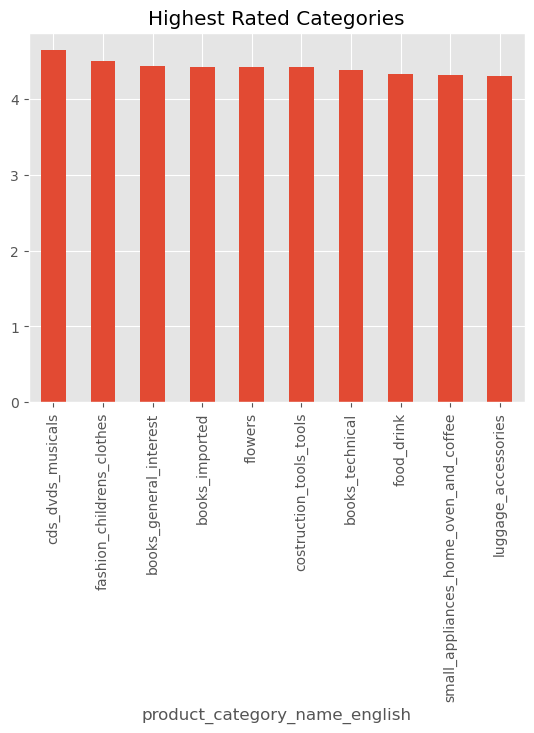

In [24]:
review_analysis.head(10).plot(
    kind="bar"
)

plt.title(
    "Highest Rated Categories"
)

plt.show()

**Business Question 9**

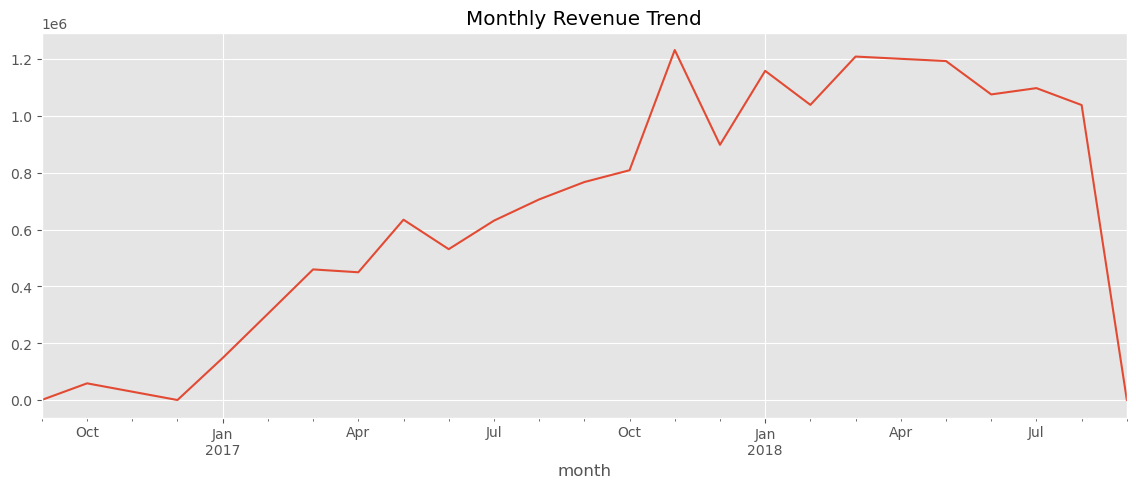

In [26]:
# Sales trend over time
merged["month"] = (
    merged["order_purchase_timestamp"]
    .dt.to_period("M")
)

sales_trend = (
    merged
    .groupby("month")
    ["revenue"]
    .sum()
)

sales_trend.plot(
    figsize=(14,5)
)

plt.title(
    "Monthly Revenue Trend"
)

plt.show()

**BUsiness Question 10**

In [27]:
#Repeat Customers
customer_orders = (
    merged
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

repeat_customers = (
    customer_orders > 1
).sum()

one_time_customers = (
    customer_orders == 1
).sum()

print(
    "Repeat Customers:",
    repeat_customers
)

print(
    "One Time Customers:",
    one_time_customers
)

Repeat Customers: 2913
One Time Customers: 92507


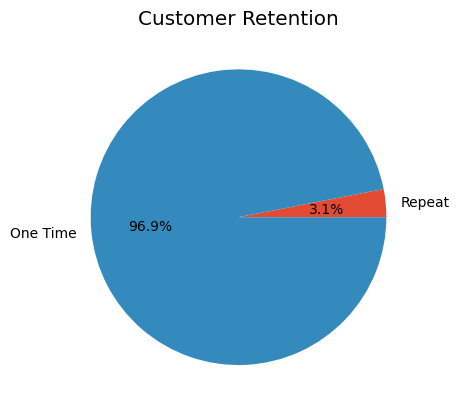

In [28]:
plt.pie(
    [repeat_customers,
     one_time_customers],

    labels=[
        "Repeat",
        "One Time"
    ],

    autopct="%1.1f%%"
)

plt.title(
    "Customer Retention"
)

plt.show()

**Business Question 11**

In [29]:
#Data Quality Report
quality_report = pd.DataFrame({
    "Missing Values":
        merged.isnull().sum(),

    "Data Type":
        merged.dtypes
})

quality_report

,Missing Values,Data Type
order_id,0,object
order_item_id,0,int64
product_id,0,object
seller_id,0,object
shipping_limit_date,0,object
price,0,float64
freight_value,0,float64
product_category_name,0,object
product_name_lenght,1709,float64
product_description_lenght,1709,float64


**Business Question 12**

In [30]:
#Merge Validation
print(
    "Orders Shape:",
    orders.shape
)

print(
    "Merged Shape:",
    merged.shape
)

print(
    "Missing Order IDs:",
    merged["order_id"]
    .isnull()
    .sum()
)

print(
    "Missing Product IDs:",
    merged["product_id"]
    .isnull()
    .sum()
)

Orders Shape: (99441, 8)
Merged Shape: (118310, 42)
Missing Order IDs: 0
Missing Product IDs: 0


**Correlation Heatmap**

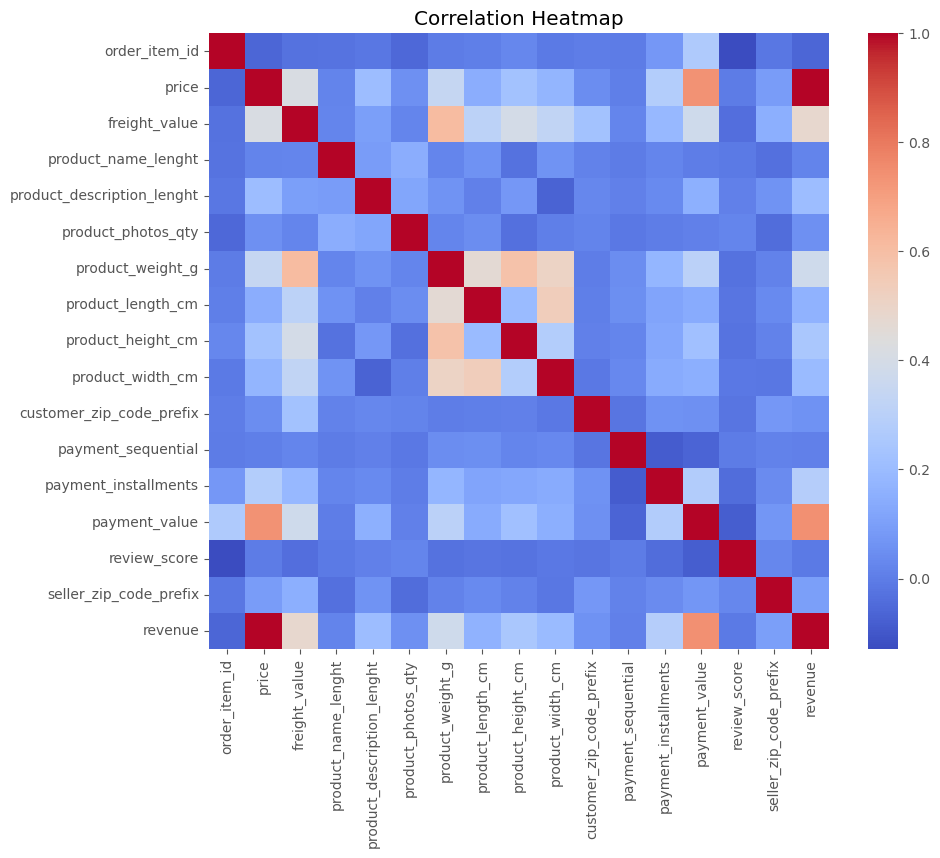

In [31]:
numeric_cols = merged.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()